# BioSample input vs. curated output, by data source

This RO-Crate (`data/2026-06_mistral-small3.1-24b/`) is the packaged output of [bsllmner-mk2](https://github.com/dbcls/bsllmner-mk2): it ran an LLM (NER extraction) plus an ontology-search pipeline over BioSample records from ChIP-Atlas and DDBJ/NCBI/EBI RNA-Seq, producing one ontology-mapped result file per input file. A separate project, [bsllmner-viewer](https://github.com/dbcls/bsllmner-viewer), consumes the same `inputs/*.jsonl` + `results/select_*.json` pair shape to build a browsable Streamlit UI over it.

The crate covers four BioSample sources: DDBJ RNA-Seq (human and mouse) and ChIP-Atlas (human/hg38 and mouse/mm10). This notebook only looks at `inputs/*.jsonl` (the raw BioSample records) and `results/select_*.json` (the curated, final output) -- not the crate's `config/`, `ontology/` or `logs/` directories, which describe how the pipeline ran rather than what the data itself contains. `provenance/run_index.tsv` is used only as a lookup table (which input file pairs with which result file, how many records each holds), not for any pipeline detail. For each of the four sources, this shows what the raw input record looks like, what the curated output record looks like, and how they pair up (matched by the shared `accession` field), how many records each source contributes, and whether the same BioSample accession ever shows up in both a ChIP-Atlas file and a DDBJ RNA-Seq file.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("biosample_input_output_pilot.ipynb")

### Table of contents


[BioSample input vs. curated output, by data source](#BioSample-input-vs.-curated-output,-by-data-source)
- [Setup](#Setup)
  - [The four categories](#The-four-categories)
  - [Showing a record: tables only](#Showing-a-record:-tables-only)
- [What's in the raw input and the curated output](#What's-in-the-raw-input-and-the-curated-output)
- [Distribution across the four categories](#Distribution-across-the-four-categories)
- [Overlap between ChIP-Atlas and DDBJ RNA-Seq](#Overlap-between-ChIP-Atlas-and-DDBJ-RNA-Seq)
- [One paired example per category](#One-paired-example-per-category)
- [Trace-back check, full crate](#Trace-back-check,-full-crate)
  - [One example per strategy](#One-example-per-strategy)
  - [100 random "not found" cases, read by hand](#100-random-"not-found"-cases,-read-by-hand)
  - [Potential fix, per failure mode](#Potential-fix,-per-failure-mode)
  - [LLM tier: judgment calls the deterministic cascade can't make](#LLM-tier:-judgment-calls-the-deterministic-cascade-can't-make)
  - [What shaped this design](#What-shaped-this-design)
- [Known pipeline issues, out of scope for this notebook](#Known-pipeline-issues,-out-of-scope-for-this-notebook)
  - [Ontology mapper accepts a coincidental short-symbol match instead of returning no match](#Ontology-mapper-accepts-a-coincidental-short-symbol-match-instead-of-returning-no-match)
  - [Correct extraction, wrong nearby term](#Correct-extraction,-wrong-nearby-term)
  - [Negation swallowed into a confidently-named, wrong compound](#Negation-swallowed-into-a-confidently-named,-wrong-compound)
  - [General fabrication rate, projected onto the full crate](#General-fabrication-rate,-projected-onto-the-full-crate)

## Setup

In [2]:
# IMPORTS
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from bs_entries import (
    MATCH_STRATEGIES,
    bold_span_html,
    bs_record_table,
    find_bs_entry,
    find_bs_entry_in_files,
    get_accession,
    iter_bs_entries,
    matches_display_table,
    scan_accessions,
    verify_extracted_against_raw,
    verify_extracted_against_raw_rows,
)
from llm_evidence import verify_not_found_with_llm
from notebook_utils import display_with_nested_tables, md, table_covers_json
from ontology import build_field_ontology_indexes
from paths import (
    CRATE_CONFIG_DIR,
    CRATE_INPUTS_DIR,
    CRATE_ONTOLOGY_DIR,
    CRATE_RESULTS_DIR,
    MANUAL_REVIEW_SAMPLE_PARQUET,
    RUN_INDEX_TSV,
    TRACE_BACK_FULL_PARQUET,
)
from select_results import curated_entry_table, find_entry, load_select_result

/workspace/BH26/BH26_BioSample_curation/.conda_env/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


### The four categories

Each category is a group of runs in `provenance/run_index.tsv` (one row per run = one input file -> one result file), identified by matching the start of the `dataset` column.

In [3]:
# THE FOUR CATEGORIES, AS A FILTER OVER run_index.tsv's `dataset` COLUMN
@dataclass(frozen=True)
class Category:
    name: str
    organism: str
    technology: str
    dataset_prefix: str  # matches run_index.tsv's `dataset` column by startswith


CATEGORIES = [
    Category("DDBJ RNA-Seq", "Homo sapiens", "RNA-Seq", "rnaseq_human"),
    Category("DDBJ RNA-Seq", "Mus musculus", "RNA-Seq", "rnaseq_mouse"),
    Category("ChIP-Atlas", "Homo sapiens", "ChIP-Atlas (hg38)", "chipatlas_hg38"),
    Category("ChIP-Atlas", "Mus musculus", "ChIP-Atlas (mm10)", "chipatlas_mm10"),
]

run_index = pd.read_csv(RUN_INDEX_TSV, sep="\t")


def category_input_files(category: Category) -> list[Path]:
    datasets = sorted(run_index.loc[run_index["dataset"].str.startswith(category.dataset_prefix), "dataset"].unique())
    files: list[Path] = []
    for dataset in datasets:
        files.extend(sorted((CRATE_INPUTS_DIR / dataset).glob("bs_entries_*.jsonl")))
    return files

In [4]:
# ONTOLOGY INDEXES, BUILT ONCE PER SELECT CONFIG AND REUSED EVERYWHERE THEY'RE NEEDED
_ontology_indexes_cache: dict[str, dict] = {}


def get_ontology_indexes(select_config_filename: str) -> dict:
    if select_config_filename not in _ontology_indexes_cache:
        with (CRATE_CONFIG_DIR / select_config_filename).open() as f:
            select_config = json.load(f)
        fields = list(select_config.get("fields", {}).keys())
        _ontology_indexes_cache[select_config_filename] = build_field_ontology_indexes(select_config, CRATE_ONTOLOGY_DIR, fields)
    return _ontology_indexes_cache[select_config_filename]

### Showing a record: tables only

Every raw/curated record below is shown as a readable table (built by `bs_record_table`/`curated_entry_table` -- every field, including empty ones, nothing filtered out). The tables are verified once, live, against the underlying JSON (`notebook_utils.table_covers_json`) to confirm they actually reproduce every value -- the JSON itself is never printed, since the table already covers it.

In [5]:
# SHOW A RECORD AS A TABLE, WITH A ONE-TIME LIVE COMPLETENESS CHECK AGAINST THE JSON
checked_complete = {"raw": False, "curated": False}


def show_raw_record(raw_record: dict, label: str) -> None:
    table = bs_record_table(raw_record)
    if not checked_complete["raw"]:
        covers = table_covers_json(raw_record, table)
        md(f"(Live-verified: this table format reproduces every value in the raw JSON: **{covers}**.)")
        checked_complete["raw"] = True
    md(f"**{label}:**")
    display_with_nested_tables(table)


def show_curated_record(entry: dict, label: str) -> None:
    table = curated_entry_table(entry)
    md(f"**{label}:**")
    display_with_nested_tables(table)
    if not checked_complete["curated"]:
        trimmed = {"extracted": entry["extract"]["extracted"], "results": entry["results"]}
        covers = table_covers_json(trimmed, table)
        md(f"(Live-verified: this table format reproduces every value in the curated JSON: **{covers}**.)")
        checked_complete["curated"] = True

## What's in the raw input and the curated output

Every input file under `inputs/` is a JSONL of raw NCBI/DDBJ/EBI BioSample records (submitter title, organism, free-text/structured attributes). Every result file under `results/` is a `SelectResult`: for each input record (matched by its `accession`), the values an LLM extracted from it (`extract.extracted`) and the ontology terms those values were mapped to (`results`). That `accession` match is the only thing pairing one to the other -- there's no positional/line-number link.

## Distribution across the four categories

Record and run counts per category, computed live from `run_index.tsv`:

In [6]:
# RECORD/RUN COUNTS PER CATEGORY
def category_counts(categories: list[Category]) -> pd.DataFrame:
    rows = []
    for cat in categories:
        subset = run_index[run_index["dataset"].str.startswith(cat.dataset_prefix)]
        rows.append(
            {
                "category": cat.name,
                "organism": cat.organism,
                "technology": cat.technology,
                "n_runs": len(subset),
                "n_records": int(subset["total_input_entries"].sum()),
            }
        )
    counts = pd.DataFrame(rows)
    counts["n_records"] = counts["n_records"].map("{:,}".format)
    return counts


category_counts(CATEGORIES)

,category,organism,technology,n_runs,n_records
0,DDBJ RNA-Seq,Homo sapiens,RNA-Seq,148,"2,111,841"
1,DDBJ RNA-Seq,Mus musculus,RNA-Seq,149,"1,747,288"
2,ChIP-Atlas,Homo sapiens,ChIP-Atlas (hg38),7,"179,015"
3,ChIP-Atlas,Mus musculus,ChIP-Atlas (mm10),7,"188,122"


`total_input_entries` sums to the number of raw BioSample records available; the DDBJ RNA-Seq split is assay-pure by construction, but ChIP-Atlas is not -- it indexes ChIP-seq, ATAC-Seq, DNase-Seq and more under one crawl, and this crate's local files don't carry a per-record assay label for it (that classification lives in ChIP-Atlas's own metadata, outside this crate), so the "technology" column above is a single collapsed label for the whole ChIP-Atlas crawl rather than a per-assay breakdown.

## Overlap between ChIP-Atlas and DDBJ RNA-Seq

ChIP-Atlas and DDBJ RNA-Seq are two separate crawls over BioSample, not disjoint-by-construction data sources -- so the same physical BioSample accession can in principle appear in both. Checked directly by comparing the full accession sets from each source's input files, per organism:

In [7]:
# ACCESSION-SET OVERLAP BETWEEN ChIP-Atlas AND DDBJ RNA-Seq, PER ORGANISM
accession_sets = {cat.dataset_prefix: scan_accessions(category_input_files(cat)) for cat in CATEGORIES}


def overlap_row(organism: str, chip_prefix: str, ddbj_prefix: str) -> dict:
    chip_set = accession_sets[chip_prefix]
    ddbj_set = accession_sets[ddbj_prefix]
    overlap = chip_set & ddbj_set
    return {
        "organism": organism,
        "chip_atlas_n": f"{len(chip_set):,}",
        "ddbj_rnaseq_n": f"{len(ddbj_set):,}",
        "overlap_n": f"{len(overlap):,}",
        "pct_of_chip_atlas": round(100 * len(overlap) / len(chip_set), 2),
        "pct_of_ddbj_rnaseq": round(100 * len(overlap) / len(ddbj_set), 2),
    }


overlap_table = pd.DataFrame(
    [
        overlap_row("Homo sapiens", "chipatlas_hg38", "rnaseq_human"),
        overlap_row("Mus musculus", "chipatlas_mm10", "rnaseq_mouse"),
    ]
)
overlap_table

,organism,chip_atlas_n,ddbj_rnaseq_n,overlap_n,pct_of_chip_atlas,pct_of_ddbj_rnaseq
0,Homo sapiens,"179,015","2,097,428",899,0.50,0.04
1,Mus musculus,"188,122","1,724,474",432,0.23,0.03


So the two sources are mostly disjoint but not entirely: a small fraction of accessions belong to both. Manually checking a few of the overlapping accessions' titles turns up two plausible explanations, and this crate's local data can't fully distinguish between them: some are multi-assay submissions (e.g. ENCODE biosamples, where one donor/tissue-prep BioSample record is shared by several different sequencing experiments -- ChIP-seq, RNA-seq, etc. -- against it), and ChIP-Atlas's own classification includes non-ChIP-seq track types (it also indexes RNA-Seq, ATAC-Seq, DNase-Seq, etc., a per-record label this crate's local files don't carry -- that lives in ChIP-Atlas's own `experimentList.tab`, external to this crate). This is not a gap in the pipeline: DDBJ RNA-Seq was deliberately scoped to RNA-Seq-assay BioSamples only, and most ChIP-Atlas accessions are not RNA-Seq experiments to begin with, so there's no reason to expect them to show up in the RNA-Seq crawl at all. The tiny overlap that does exist represents genuine dual-use samples, not something the pipeline "missed."

One overlapping accession per organism, both raw copies merged into one table (field, ChIP-Atlas value, DDBJ RNA-Seq value) so they're easy to compare directly -- any scalar field where the two sources disagree is **bolded** on both sides:

In [8]:
# ONE ACCESSION PRESENT IN BOTH SOURCES, PER ORGANISM -- MERGED INTO ONE COMPARISON TABLE
def merged_overlap_table(chip_record: dict, ddbj_record: dict) -> pd.DataFrame:
    chip_row = bs_record_table(chip_record).iloc[0]
    ddbj_row = bs_record_table(ddbj_record).iloc[0]

    rows = []
    for field in chip_row.index:
        chip_val, ddbj_val = chip_row[field], ddbj_row[field]
        if isinstance(chip_val, pd.DataFrame) or isinstance(ddbj_val, pd.DataFrame):
            # nested (attributes/ids/links) -- shown as-is, side by side, rather than diffed row-by-row
            rows.append({"field": field, "ChIP-Atlas": chip_val, "DDBJ RNA-Seq": ddbj_val})
            continue
        differs = str(chip_val) != str(ddbj_val)
        if differs:
            chip_val = bold_span_html(str(chip_val), (0, len(str(chip_val))))
            ddbj_val = bold_span_html(str(ddbj_val), (0, len(str(ddbj_val))))
        rows.append({"field": field, "ChIP-Atlas": chip_val, "DDBJ RNA-Seq": ddbj_val})
    return pd.DataFrame(rows, columns=["field", "ChIP-Atlas", "DDBJ RNA-Seq"])


def show_overlap_example(organism: str, chip_prefix: str, ddbj_prefix: str) -> None:
    overlap = accession_sets[chip_prefix] & accession_sets[ddbj_prefix]
    accession = min(overlap)

    chip_category = next(c for c in CATEGORIES if c.dataset_prefix == chip_prefix)
    ddbj_category = next(c for c in CATEGORIES if c.dataset_prefix == ddbj_prefix)

    chip_record = find_bs_entry_in_files(category_input_files(chip_category), accession)
    ddbj_record = find_bs_entry_in_files(category_input_files(ddbj_category), accession)

    md(f"### {organism}: accession `{accession}`, in both ChIP-Atlas and DDBJ RNA-Seq")
    display_with_nested_tables(merged_overlap_table(chip_record, ddbj_record))


for organism, chip_prefix, ddbj_prefix in [
    ("Homo sapiens", "chipatlas_hg38", "rnaseq_human"),
    ("Mus musculus", "chipatlas_mm10", "rnaseq_mouse"),
]:
    show_overlap_example(organism, chip_prefix, ddbj_prefix)

### Homo sapiens: accession `SAMD00005178`, in both ChIP-Atlas and DDBJ RNA-Seq

field,ChIP-Atlas,DDBJ RNA-Seq
accession,SAMD00005178,SAMD00005178
internal_id,,
organism,Homo sapiens,Homo sapiens
taxonomy_id,9606,9606
title,10589-108D4,10589-108D4
sample_name,DRS007724,DRS007724
comment,,
access,public,public
submission_date,,
publication_date,2014-03-28T00:00:00+09:00,2014-03-28T00:00:00+09:00


### Mus musculus: accession `SAMD00004148`, in both ChIP-Atlas and DDBJ RNA-Seq

field,ChIP-Atlas,DDBJ RNA-Seq
accession,SAMD00004148,SAMD00004148
internal_id,,
organism,Mus musculus,Mus musculus
taxonomy_id,10090,10090
title,ZHBTc4 mouse ES cells stably expressing Flag-MacroH2A variant,ZHBTc4 mouse ES cells stably expressing Flag-MacroH2A variant
sample_name,DRS011871,DRS011871
comment,,
access,public,public
submission_date,,
publication_date,2013-06-25T00:00:00+09:00,2013-06-25T00:00:00+09:00


## One paired example per category

For each category, the smallest run's first record: the raw input as stored, and its matching curated entry, joined by `accession`. The header on each names the category and organism explicitly.

Each example ends with a deterministic trace-back check: for every non-null extracted field, does that value appear anywhere in the raw record -- checked first against every `Attributes` entry (in list order, including each attribute's own NAME, not just its content); only if none of them match at all is `Title`/`Description.Comment.Paragraph` checked as a fallback. Within a group, tiers are tried in order -- exact, case-insensitive, normalized (parenthetical/punctuation-insensitive), ontology synonym, fuzzy (spelling-tolerant, long words only) -- see `MATCH_STRATEGIES` and the "full crate" section below for what each one means. When a value matches more than one attribute, all of those matches are shown, not just the first. `matches` shows where it was found and the matched text in **bold**.


In [9]:
# PICK ONE (INPUT FILE, RESULT FILE) PER CATEGORY -- SMALLEST RUN, FOR A QUICK READ
def pick_example_run(category: Category) -> pd.Series:
    subset = run_index[(run_index["dataset"].str.startswith(category.dataset_prefix)) & (run_index["status"] == "completed")]
    return subset.loc[subset["total_input_entries"].idxmin()]


def show_paired_example(category: Category) -> None:
    run = pick_example_run(category)
    input_path = CRATE_INPUTS_DIR / run["dataset"] / run["input_file"]
    result_path = CRATE_RESULTS_DIR / run["result_file"]

    raw_record = next(iter_bs_entries(input_path))
    accession = get_accession(raw_record)

    select_result = load_select_result(result_path)
    curated_entry = find_entry(select_result, accession)
    ontology_indexes = get_ontology_indexes(run["select_config"])

    md(f"### {category.name} -- {category.organism} (`{run['run_name']}`, accession `{accession}`)")
    show_raw_record(raw_record, "Raw input")
    show_curated_record(curated_entry, "Curated output")

    md("**Tracing extracted values back to the raw input:**")
    trace_back_example = verify_extracted_against_raw(raw_record, curated_entry["extract"]["extracted"], curated_entry["results"], ontology_indexes)
    display_with_nested_tables(trace_back_example[["raw_field", "raw_value", "strategy", "matches", "n_matches", "assigned_term_id", "assigned_term_label"]])


for category in CATEGORIES:
    show_paired_example(category)

### DDBJ RNA-Seq -- Homo sapiens (`rnaseq_human_past_2014-09`, accession `SAMN01731102`)

(Live-verified: this table format reproduces every value in the raw JSON: **False**.)

**Raw input:**

**Curated output:**

extracted,results
field,value
cell_line,
cell_type,human umbilical vein endothelial cell
chip_antigen,
disease,
drug,
knockdown_gene,
knockout_gene,
overexpressed_gene,
tissue,


...

### ChIP-Atlas -- Mus musculus (`chipatlas_mm10_part5`, accession `SAMD00015968`)

**Raw input:**

**Curated output:**

extracted,results
field,value
cell_line,
cell_type,
chip_antigen,
disease,
drug,
knockdown_gene,
knockout_gene,
overexpressed_gene,MyoD
tissue,


**Tracing extracted values back to the raw input:**

## Trace-back check, full crate

The single-example check above, run over the entire crate -- every category, every run, ~4.2M BioSamples -- from a parquet built once by a standalone script (see `src/ontology.py`/`src/bs_entries.py` for the checked-in matching logic itself, unchanged from the single-example check above).

Every tier checks every `Attributes` entry first (including each attribute's own NAME) and only falls back to `Title`/`Description.Comment.Paragraph` if nothing in `Attributes` matched. Every substring-based tier also requires a genuine word boundary on both edges of the match -- found directly on real data: `"in vitro"` is a literal substring of `"Invitrogen"` (a reagent brand, unrelated), and `"Ap"` is a literal substring of `"applicable"`; neither is a real match, and both are now rejected. Within a group, tiers are tried in this order:

1. **Exact** -- byte-identical substring.
2. **Case-insensitive**.
3. **Normalized** -- case-insensitive, with parentheticals stripped, tried two ways: separators (hyphens/underscores/whitespace) collapsed to one space (matches `"Sinoatrial node cell"` inside `"Sinoatrial node (SAN) cells"`), and separately with separators removed entirely (matches `"HEK293"` inside `"HEK 293"`, or `"Oct4"` inside `"oct_4"` -- a boundary present on only one side, which collapsing alone can't bridge).
4. **Ontology synonym** -- does the LABEL or a registered SYNONYM of the ontology term `results` actually assigned appear in the text? Not the extracted value's own wording at all, but a curated alternative name for it.
5. **Fuzzy** -- spelling-tolerant word-by-word match of the value itself, only for words of 6+ characters, with an edit-distance budget that scales with word length and never touches digit characters (e.g. catches `"Gliobmastoma"` for `"Glioblastoma"`, but never merges two genuinely different identifiers like `CD4`/`CD8` or `miR-16`/`miR-15`). Tried dead last, after every other option, since it's the one tier not backed by an exact or curated match.

In [10]:
# LOAD PRE-COMPUTED FULL-CRATE RESULTS
trace_back_full = pd.read_parquet(TRACE_BACK_FULL_PARQUET)

total_completed_runs = (run_index["status"] == "completed").sum()
loaded_runs = trace_back_full["run_name"].nunique()
loaded_categories = sorted(
    f"{cat} ({org})" for cat, org in trace_back_full[["category", "organism"]].drop_duplicates().itertuples(index=False)
)

md(
    f"Loaded **{len(trace_back_full):,} non-null extracted field values** from "
    f"**{trace_back_full['accession'].nunique():,} BioSamples**, covering **{loaded_runs} of {total_completed_runs} completed runs** "
    f"in the crate ({', '.join(loaded_categories)})."
    + (
        ""
        if loaded_runs == total_completed_runs
        else " The remaining categories are still being processed in the background; this section updates in place once they finish."
    )
)

Loaded **8,194,813 non-null extracted field values** from **3,989,387 BioSamples**, covering **311 of 311 completed runs** in the crate (ChIP-Atlas (Homo sapiens), ChIP-Atlas (Mus musculus), DDBJ RNA-Seq (Homo sapiens), DDBJ RNA-Seq (Mus musculus)).

### % deterministically traced, per extracted field

Per field, only over the BioSamples where that field actually had a non-null extracted value (a null extraction is excluded entirely, not counted as a failure). Broken down by which tier found it -- see the section intro above for what each of `exact`/`case-insensitive`/`normalized`/`ontology synonym`/`fuzzy` means -- else not found at all.

In [11]:
# COUNTS PER (FIELD, STRATEGY), EXCLUDING FIELDS WITH NO EXTRACTED VALUE
STRATEGY_ORDER = [*MATCH_STRATEGIES, "not found"]


def strategy_breakdown(trace_back: pd.DataFrame) -> pd.DataFrame:
    counts = trace_back.groupby(["raw_field", "strategy"]).size().unstack(fill_value=0)
    counts.columns.name = None  # unstack() leaves "strategy" as the column axis's name, which pandas prints as a spurious extra header row
    for strategy in STRATEGY_ORDER:
        if strategy not in counts.columns:
            counts[strategy] = 0
    counts = counts[STRATEGY_ORDER]
    counts["n_with_value"] = counts.sum(axis=1)
    counts["pct_found"] = (100 * (counts["n_with_value"] - counts["not found"]) / counts["n_with_value"]).round(1)
    return counts.reset_index().sort_values("pct_found").reset_index(drop=True)

In [12]:
# % DETERMINISTICALLY TRACED, PER FIELD
strategy_stats_full = strategy_breakdown(trace_back_full)
strategy_stats_full.style.format({**{col: "{:,}" for col in [*STRATEGY_ORDER, "n_with_value"]}, "pct_found": "{:.1f}"})

,raw_field,exact,case-insensitive,normalized,ontology synonym,fuzzy,not found,n_with_value,pct_found
0,knockdown_gene,"54,561","1,649",189,528,176,"28,433","85,536",66.8
1,knockout_gene,"330,733","8,965","1,478","11,139","1,544","90,604","444,463",79.6
2,overexpressed_gene,"164,950","5,579",320,"1,539",241,"33,923","206,552",83.6
3,cell_type,"1,485,385","36,113","8,078","15,085","118,269","227,565","1,890,495",88.0
4,disease,"532,982","46,299","1,309","14,840","5,966","33,636","635,032",94.7
5,tissue,"2,463,951","195,524","4,432","3,605","23,823","103,664","2,794,999",96.3
6,drug,"745,100","14,407","3,211","5,916","1,987","21,007","791,628",97.3
7,chip_antigen,"346,859","4,160","1,203","1,170",153,"7,197","360,742",98.0
8,cell_line,"963,492","6,106","8,450","1,495",720,"5,103","985,366",99.5


In [13]:
# % TRACED BACK PER STRATEGY, ACROSS ALL FIELDS COMBINED
total_checked = len(trace_back_full)
strategy_totals = trace_back_full["strategy"].value_counts().reindex(STRATEGY_ORDER, fill_value=0)

md(
    f"Across all **{total_checked:,}** extracted field values checked: "
    + ", ".join(f"**{n:,} ({100 * n / total_checked:.1f}%)** by `{strategy}`" for strategy, n in strategy_totals.items())
    + "."
)

Across all **8,194,813** extracted field values checked: **7,088,013 (86.5%)** by `exact`, **318,802 (3.9%)** by `case-insensitive`, **28,670 (0.3%)** by `normalized`, **55,317 (0.7%)** by `ontology synonym`, **152,879 (1.9%)** by `fuzzy`, **551,132 (6.7%)** by `not found`.

In [14]:
# HOW OFTEN A VALUE MATCHES MORE THAN ONE ATTRIBUTE
found_full = trace_back_full[trace_back_full["strategy"] != "not found"]
multi_match_full = found_full[found_full["n_matches"] > 1]

md(
    f"Of the **{len(found_full):,} extracted values traced back successfully**, **{len(multi_match_full):,} ({100 * len(multi_match_full) / len(found_full):.1f}%)** "
    f"matched more than one attribute -- after `_preferred_matches` (`src/bs_entries.py`) already drops a `source_name`/`sample_name` match whenever "
    f"a normal attribute (e.g. `cell_line`) also matched, since those two are generic catch-alls that just restate a more specific field rather than "
    f"an independent confirmation. What's left here is genuine ambiguity between two equally-specific attributes (e.g. `cell_type` and `disease` both "
    f"happening to contain the word \"cancer\", or the same fact embedded in more than one identifier field)."
)

Of the **7,643,681 extracted values traced back successfully**, **577,226 (7.6%)** matched more than one attribute -- after `_preferred_matches` (`src/bs_entries.py`) already drops a `source_name`/`sample_name` match whenever a normal attribute (e.g. `cell_line`) also matched, since those two are generic catch-alls that just restate a more specific field rather than an independent confirmation. What's left here is genuine ambiguity between two equally-specific attributes (e.g. `cell_type` and `disease` both happening to contain the word "cancer", or the same fact embedded in more than one identifier field).

In [15]:
# STACKED PLOT: % OF EXTRACTIONS FOUND PER TIER, PER FIELD
def _select_label_positions(candidates: list[float], min_gap: float = 6.0) -> list[float]:
    """From candidate label positions (cumulative % boundaries on one bar), picks which to
    actually render as text: always the largest, then each next-largest only if it's at
    least `min_gap` percentage points from the last one kept -- otherwise two close
    boundaries produce overlapping, unreadable text (e.g. 58% and 59% back to back).
    """
    ordered = sorted(set(candidates), reverse=True)
    kept: list[float] = []
    for value in ordered:
        if not kept or (kept[-1] - value) >= min_gap:
            kept.append(value)
    return kept


def plot_strategy_breakdown(stats: pd.DataFrame, figsize: tuple[float, float] = (9, 6)) -> None:
    order = STRATEGY_ORDER
    # ordinal blue ramp for the matched tiers (darkest = strongest match), light red for failure --
    # all >=8:1 black-text contrast, checked with the same formula the dataviz skill's validator uses
    colors = {
        "exact": "#6da7ec",
        "case-insensitive": "#89b8ef",
        "normalized": "#a8c9f4",
        "ontology synonym": "#c6daf8",
        "fuzzy": "#e3eefc",
        "not found": "#eb9a9a",
    }

    fields = stats.sort_values("pct_found")["raw_field"].tolist()
    pct = stats.set_index("raw_field")
    pct = pct[order].div(pct["n_with_value"], axis=0) * 100
    pct = pct.loc[fields]

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = list(range(len(fields)))
    left = pd.Series(0.0, index=pct.index)
    for strategy in order:
        ax.barh(y_pos, pct[strategy], left=left, label=strategy, color=colors[strategy])
        left += pct[strategy]

    for y, field in zip(y_pos, fields):
        # candidate label positions are cumulative boundaries over the MATCHED tiers only (never
        # "not found", whose own boundary is trivially ~100% and tells the reader nothing) -- this
        # makes the largest candidate always `pct_found`, the one number that matters most, and
        # guarantees it's always the one shown even when the last matched slice is thin
        cum = 0.0
        candidates = []
        for strategy in MATCH_STRATEGIES:
            cum += pct.loc[field, strategy]
            if pct.loc[field, strategy] > 0:
                candidates.append(cum)
        for value in _select_label_positions(candidates):
            ax.text(value - 1, y, f"{value:.0f}", va="center", ha="right", fontsize=9, color="black")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fields)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of non-null extractions")
    ax.set_title("How extracted values were traced back to the raw input, by field")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

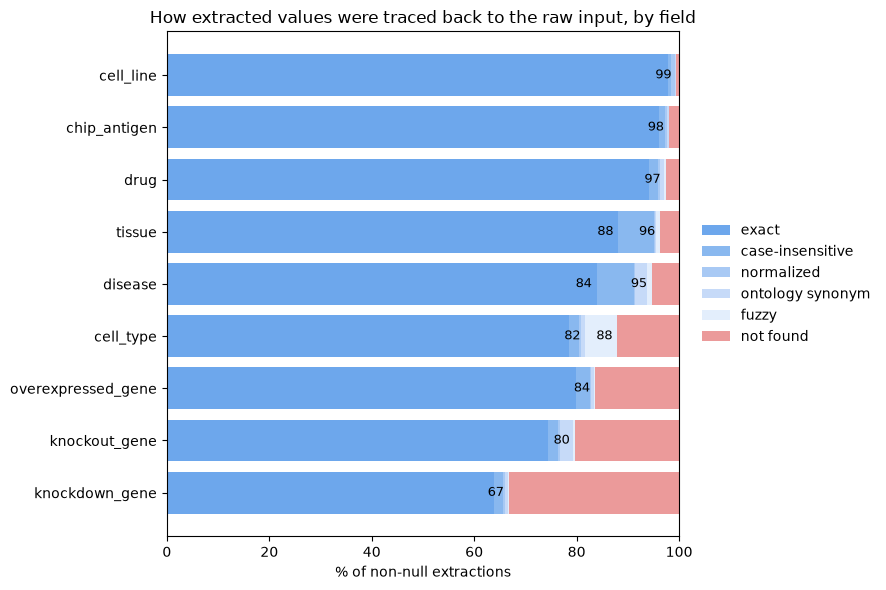

In [16]:
# STACKED PLOT OF strategy_stats_full
plot_strategy_breakdown(strategy_stats_full)

### One example per strategy

The first BioSample/field pair (in the order checked) resolved by each tier -- `matches` bolds whatever span that tier actually matched, one row per attribute it was found in when there's more than one. For the `ontology synonym` row specifically, the bolded span in `matches` is NOT the extracted value's own text -- it's whichever of `assigned_term_label`/`assigned_term_synonyms` actually appears in the raw record; `assigned_term_synonyms` lists every synonym the assigned ontology term has, so you can see the exact alternative name that made the match (e.g. `raw_value="HEK293T"` traces back via the bolded `"293T"`, which `assigned_term_synonyms` confirms is a registered synonym of the assigned term `HEK293T`). `assigned_term_id`/`assigned_term_label`/`assigned_term_synonyms` are shown for every strategy, not just this one, since `results` assigns a term regardless of which tier ultimately found the match.

In [17]:
# ONE EXAMPLE PER STRATEGY: biosample_id | strategy | field | raw_value | matches | assigned_term_id | assigned_term_label | assigned_term_synonyms
def one_example_per_strategy(trace_back: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy in STRATEGY_ORDER:
        subset = trace_back[trace_back["strategy"] == strategy]
        if len(subset) == 0:
            continue
        row = subset.iloc[0]
        rows.append(
            {
                "biosample_id": row["accession"],
                "strategy": strategy,
                "field": row["raw_field"],
                "raw_value": row["raw_value"],
                "matches": matches_display_table(row["curated_fields"], row["curated_texts"], row["curated_matched_phrase"]),
                "assigned_term_id": row["assigned_term_id"],
                "assigned_term_label": row["assigned_term_label"],
                "assigned_term_synonyms": row["assigned_term_synonyms"],
            }
        )
    return pd.DataFrame(rows, columns=["biosample_id", "strategy", "field", "raw_value", "matches", "assigned_term_id", "assigned_term_label", "assigned_term_synonyms"])


display_with_nested_tables(one_example_per_strategy(trace_back_full))

### 100 random "not found" cases, read by hand

Not every "not found" row is a distinct failure -- the same failure pattern (e.g. one study's LLM-added suffix, repeated over hundreds of near-identical BioSamples) can dominate a plain random sample. So this first drops duplicates on `(raw_field, raw_value)` across the full crate's "not found" rows, then draws a fixed-seed sample of 100 *distinct* patterns from what remains, frozen to `data/derived/manual_review_sample_100.parquet` -- this table is a fixed historical sample for hand review, not something that should silently change on every future re-run the way the live stats above do.

In [18]:
# THE 100 SAMPLED "NOT FOUND" ROWS (FIXED SNAPSHOT), WITH THEIR ONTOLOGY ENRICHMENT
manual_review_sample = pd.read_parquet(MANUAL_REVIEW_SAMPLE_PARQUET)
manual_review_sample

,accession,run_name,category,organism,raw_field,raw_value,assigned_term_id,assigned_term_label,assigned_term_synonyms
0,SAMN19116347,rnaseq_human_5y_2021-12,DDBJ RNA-Seq,Homo sapiens,disease,Asthma,MONDO:0004979,asthma,bronchial hyperreactivity
1,SAMN26541934,chipatlas_hg38_part1,ChIP-Atlas,Homo sapiens,overexpressed_gene,VEGFA,NCBIGene:5238,PGM3,AGM1; IMD23; PAGM; PGM 3
2,SAMN22555214,rnaseq_human_5y_2021-12,DDBJ RNA-Seq,Homo sapiens,tissue,dendritic cell,,,
3,SAMN17170426,rnaseq_mouse_2021-04,DDBJ RNA-Seq,Mus musculus,chip_antigen,I-A/E,,,
4,SAMN00739107,chipatlas_hg38_part4,ChIP-Atlas,Homo sapiens,knockout_gene,E6,,,
...,...,...,...,...,...,...,...,...,...
95,SAMN08574372,rnaseq_mouse_2018-09,DDBJ RNA-Seq,Mus musculus,knockout_gene,DM112,,,
96,SAMN01998263,rnaseq_mouse_2015-07,DDBJ RNA-Seq,Mus musculus,tissue,striatum,UBERON:0002435,striatum,neostriatum; neuraxis striatum; striate nucleu...
97,SAMN18114600,rnaseq_mouse_2021-03,DDBJ RNA-Seq,Mus musculus,cell_type,CD4+ CD90.1+ T cell,CL:0000084,T cell,T lymphocyte; T-cell; T-lymphocyte; immature T...
98,SAMN14600382,chipatlas_mm10_part1,ChIP-Atlas,Mus musculus,knockout_gene,Hnf4g,NCBIGene:15378,Hnf4a,HNF-4; Hnf4; Hnf4alpha; MODY1; Nr2a1; TCF-14; ...


Each of the 100 above, read against its raw `Attributes`/`Title`/`comment` by hand (`curated_field`/`curated_value` are the reviewer's own judgment of where the value actually comes from, if anywhere -- not computed by `verify_extracted_against_raw`):

In [19]:
# MANUAL REVIEW OF THE 100: (accession, raw_field, raw_value, curated_field, curated_text, matched_phrase, failure_mode)
MANUAL_REVIEW = [
    ('SAMN19116347', 'disease', 'Asthma', 'disease', 'Asthmatic patients', 'Asthmatic', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN26541934', 'overexpressed_gene', 'VEGFA', 'treatment', 'HEK293FT_pegHBB-RES-OT-c_MM3;...;HEK293FT_pegVEGFA-OT-a_MM3;...', 'pegVEGFA', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN22555214', 'tissue', 'dendritic cell', 'tissue', 'DC', None, 'abbreviation (raw text abbreviates the value)'),
    ('SAMN17170426', 'chip_antigen', 'I-A/E', 'sample_type', 'F4/80highI-A/Ehigh', 'I-A/Ehigh', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN00739107', 'knockout_gene', 'E6', 'cell description', 'pancreatic duct cells immortalized with E6E7 gene of HPV', 'E6E7', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN06372158', 'drug', 'KDM4 inhibitor', 'treatment', '10 nM kDM4(i) for 18 hours', 'kDM4(i)', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN37494211', 'knockout_gene', 'Ptgsc', 'genotype', 'Gli1-PtgscKO', 'PtgscKO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN11348570', 'knockout_gene', 'Cpt2', 'maternal genotype', 'Cpt2f/f', 'Cpt2f', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN22335973', 'knockout_gene', 'Gpr174', 'not found', '', None, 'fabricated / no textual basis'),
    ('SAMN36792794', 'knockout_gene', 'Fgf23c', 'genotype', 'Fgf23cKO', 'Fgf23cKO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN40861569', 'knockdown_gene', 'CDC40', 'comment', '24h KD of shCDC40-1', 'shCDC40', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN39579875', 'knockout_gene', 'Ext1', 'genotype', 'Ext1e2neof/e2neof', 'Ext1e2neof', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN04925760', 'knockdown_gene', 'COX2', 'lentiviral shrna', 'shCOX2', 'shCOX2', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN25519995', 'overexpressed_gene', 'Zfp131', 'title', 'ChIPseq NELF in Zbtb11KO Zfp131KO ES cells (iZbtb11-HA iZfp131-V5 Zbtb11KO Zfp131KO)', 'Zfp131KO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMD00171431', 'knockdown_gene', 'CALIC-1', 'title', 'siCALIC-1 Re1', 'siCALIC-1', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN35880621', 'tissue', 'buccal mucosa', 'source_name', 'Buccal cells', None, 'inferred from domain knowledge'),
    ('SAMN37211846', 'knockout_gene', 'DCAF15', 'genotype', 'G401 dTag DCAF5', None, 'fabricated / no textual basis'),
    ('SAMEA7047760', 'knockdown_gene', 'MXD1', 'comment', 'siNon-targeting siCtrl...siMXD1, Ambion, Cat. No. s8390', 'siMXD1', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMEA122004238', 'knockout_gene', 'FMR1', 'disease', 'Fragile X syndrome', None, 'inferred from domain knowledge'),
    ('SAMN01178354', 'knockdown_gene', 'Aes', 'genotype', '24h siAes; 111011', 'siAes', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN02209082', 'knockout_gene', 'Gata3', 'strain', 'C57BL/6 Gata3fl/fl, infected with hCre-GFP-RV, GFP+', 'Gata3fl', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN14124621', 'knockout_gene', 'COP1', 'genotype', 'COP1KO', 'COP1KO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN04028831', 'cell_type', 'IFNg secreting central memory CD4 T cell', 'cell_type', 'IFNg secreting central memory CD4 Tcells - CD3+ CD4+ CD45RA- CCR7+ IFNG+', None, 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN16351323', 'knockout_gene', 'Fntb', 'title', 'FntbKO_eTreg2_ATACseq', 'FntbKO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN33865542', 'drug', 'DNase I', 'treatment', 'DNase l', None, "misspelling (typo, below fuzzy's safe length threshold)"),
    ('SAMN03195908', 'knockdown_gene', 'XPB', 'targeted by', 'shXPB', 'shXPB', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN41719664', 'cell_type', 'CD4 TREG', 'cell_type + phenotype (2 separate attributes)', 'cell_type=CD4 | phenotype=TREG', None, 'value combines multiple separate attributes'),
    ('SAMN09658561', 'knockout_gene', 'a6', 'genotype', 'a3a6KO', None, 'abbreviation (raw text abbreviates the value)'),
    ('SAMN17120240', 'cell_type', 'bronchoepithelial cell', 'source_name', 'human bronchoepithelial cells', None, 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN15017513', 'knockout_gene', 'Erbb4', 'biological_replicate', 'Tu_Erbb4CKO_PLUS_ApcMin_1', 'Erbb4CKO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN01922231', 'knockout_gene', 'DOCK1', 'genotype', 'NIC+DOCK1flx/flx', 'DOCK1flx', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN30523651', 'knockdown_gene', 'BRD9', 'treatment', 'shBRD9', 'shBRD9', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN53128103', 'cell_line', 'GBM06CL', 'isolate', 'glioblastoma patient, cell line', None, 'fabricated / no textual basis'),
    ('SAMN45151549', 'cell_type', 'cardiac myocyte', 'cell_type', 'left ventricle tissue', None, 'inferred from domain knowledge'),
    ('SAMN46306599', 'knockout_gene', 'ORAI2', 'genotype', 'ORAI 1/2/3 KO', None, 'abbreviation (raw text abbreviates the value)'),
    ('SAMEA5841432', 'disease', 'mammary tumor', 'title', 'Transcriptomic study of bone marrow and mammary tumours of PyMT mice exposed to chronic jetlag', 'mammary tumours', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN18620482', 'knockdown_gene', 'RB1', 'knockdown', 'shRB', None, 'abbreviation (raw text abbreviates the value)'),
    ('SAMN18537506', 'cell_type', 'colon carcinoma cell', 'cell_type', 'Human colon carcinoma', None, 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN08897533', 'cell_type', 'HSC', 'cell_type', 'Sorted HSCs', 'HSCs', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN22321177', 'overexpressed_gene', 'Gck', 'title', 'GckPVT 4 output', 'GckPVT', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN36416300', 'cell_type', 'ILT3-CD4+CD25+ T cell', 'cell_type', 'ILT3-CD4+CD25+ T cells', 'T cells', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMEA7705308', 'knockdown_gene', 'DDIT3', 'Submitter Id', 'S-TOXR1774:PHH_siDDIT3_TUN_N1', 'siDDIT3', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN17812093', 'disease', 'colon cancer', 'source_name', 'Primary CRC', 'CRC', 'abbreviation (raw text abbreviates the value)'),
    ('SAMEA6806901', 'knockdown_gene', 'B55alpha', 'comment', 'treated with lentiviral shCtrl and shB55alpha (Sigma; TRCN0000002489)', 'shB55alpha', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN35360488', 'drug', 'immune checkpoint blockade', 'disease', 'ICB-treated HCC patients', 'ICB', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN35881425', 'knockout_gene', 'POU2AF2', 'treatment', 'sgPOU2AF2 #2', 'sgPOU2AF2', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN09394965', 'overexpressed_gene', 'Kir2.1', 'injection', 'Kir-Gfp electroporation', None, 'fabricated / no textual basis'),
    ('SAMN12558165', 'cell_type', 'myeloma cell', 'cell_type', '5TGM1-GFP Myeloma cells, bone lining', 'Myeloma cells', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN38066130', 'tissue', 'head', 'tissue', 'Wnt1-CRE recombined cells (i.e., eGFP+) cell sorted from dissocated E11.5 heads (rostral to the otic placode)', 'heads', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN40606227', 'drug', 'Thiazopyrimidine', 'treatment', 'Thiazopyr_10_uM', 'Thiazopyr', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN05230122', 'knockout_gene', 'Cic', 'genotype', 'Otp-Cre; Cicflox/flox; ROSAfsTRAP', 'Cicflox', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN08583676', 'knockout_gene', 'Plag1', 'genotype', 'Plag1KO', 'Plag1KO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN21163036', 'drug', 'Entecavir', 'treatment', 'HBV-infected (ayw, MOI 200), ETV (100 nM)-treated', 'ETV', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN06010099', 'cell_type', 'neocortical cell', 'cell_type', 'cultured primary neocortical cells', 'neocortical cells', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN11179148', 'knockout_gene', 'Rdh1', 'genotype', 'Rdh1KO', 'Rdh1KO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN49057686', 'knockout_gene', 'MSI2', 'not found', '', None, 'fabricated / no textual basis'),
    ('SAMN31891919', 'knockdown_gene', 'LINC02143', 'condition', 'siLINC2', 'LINC2', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN50497702', 'knockout_gene', 'MLP', 'title', 'double knockout (MLPKO-cRADKO) mouse heart 5, 16 weeks of age', 'MLPKO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN48196193', 'drug', 'Surufatinib', 'isolate', 'Surufatinib1', 'Surufatinib1', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN32873513', 'knockdown_gene', 'DEC2', 'not found', '', None, 'fabricated / no textual basis'),
    ('SAMN13717685', 'disease', 'Rhabdomyosarcoma', 'source_name', 'RD ERMS cell line derived from biopsy specimen of a 7year old female with pelvic RMS', 'RMS', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN39678524', 'overexpressed_gene', 'G3BP2', 'genotype', 'G3BP1/2 KO cells stably expressing transgenic mEGFP-G3BP2A', 'G3BP2A', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN14348450', 'tissue', 'lymph nodes', 'tissue', 'lymphonodes', 'lymphonodes', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN46955449', 'overexpressed_gene', 'C9ORF72', 'title', 'C9ORF72exp_CPA+FB23-2', 'C9ORF72exp', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN11969409', 'disease', 'lung carcinoma', 'source_name', 'Human lung (carcinoma) cell line', 'lung (carcinoma)', 'compound token (word/phrase inserted between parts of the value)'),
    ('SAMN38457665', 'knockout_gene', 'eIF2α', 'genotype', 'eIF2{alpha}A/A (KI)', 'eIF2{alpha}', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN22487913', 'disease', 'lupus nephritis', 'disease', 'lupus symptomatic nephritic disease', None, 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN03892686', 'knockdown_gene', 'Ren.713', 'title', 'shRen.713_RNASeq rep1', 'shRen.713', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN33550898', 'knockout_gene', 'YBX1', 'title', 'SCC25, YBX1KO, DOXneg, rep 3 [RNA-seq]', 'YBX1KO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN13519754', 'knockdown_gene', 'METTL18', 'not found', '', None, 'fabricated / no textual basis'),
    ('SAMN46220850', 'knockdown_gene', 'Nas1', 'Treated', 'siNas1-A', 'siNas1', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMD00122100', 'drug', 'Src inhibitor', 'title', 'RNA-seq_II-18_24h_D07_PD-166285 hydrate (Inhibitor_Src and FGFR)_0.42', 'Inhibitor_Src', 'reworded (word order reversed)'),
    ('SAMN25599802', 'drug', 'recombinant interleukin-17A', 'treatment_2', 'i.p and i.m. rIL-17A', 'rIL-17A', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN36617246', 'knockout_gene', 'PPM1B', 'genotype', 'Ppm1bCKO', 'Ppm1bCKO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN30812759', 'drug', 'Escherichia coli kifCD', 'treatment', 'None, C. ramosum, E. coli Nissl, E. coli kifCD', 'E. coli kifCD', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN36620907', 'knockout_gene', 'CD5', 'title', 'Donor2_CD5KO_2', 'CD5KO', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN30812759', 'drug', 'Escherichia coli Nissle', 'treatment', 'None, C. ramosum, E. coli Nissl, E. coli kifCD', 'E. coli Nissl', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN35778149', 'knockout_gene', 'Mirc11', 'genotype', 'Mirc11fl/fl Mirc22fl/fl Lyz2Cre/Cre', 'Mirc11fl', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN08177822', 'knockdown_gene', 'Chd5', 'knockdown', 'shChd5', 'shChd5', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN17072774', 'chip_antigen', 'NEUN', 'nuclei population', 'NEUNnegOLIG2neg nuclei', 'NEUNneg', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMEA14497215', 'knockdown_gene', 'Foxa2', 'title', 'CL1 siFoxa2 1', 'siFoxa2', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN17293665', 'drug', 'puromycin', 'exogenous vectors', 'pSBbi-Hyg-APP, pSBbi-Pur', 'Pur', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN03943833', 'cell_type', 'liver rhabdoid tumor cell', 'cell_type', 'liver rhabdoid tumor derived cell line', None, 'compound token (word/phrase inserted between parts of the value)'),
    ('SAMN06230985', 'knockout_gene', 'AATF', 'title', 'LALB_siAATF_3', 'siAATF', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN35036845', 'tissue', 'Trachea', 'tissue', 'Trachael aspirate', 'Trachael', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN00780189', 'cell_type', 'inducible motor neuron', 'cell_type', 'inducible motor neurons-embryonic stem cells (iMN-ESCs)', 'motor neurons', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMEA110218887', 'overexpressed_gene', 'IKK2', 'comment', 'Rb1FL/FL, p53FL/FL, R26.LSL.IKK2ca', 'IKK2ca', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN05210768', 'cell_type', 'P19 embryonal carcinoma cell', 'cell_type', 'P19 embryonal carcinoma (EC) cells treated 48 hrs with RA', 'P19 embryonal carcinoma (EC) cells', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN22984295', 'cell_type', 'thyroid epithelial cell', 'source_name', 'Human Primary Thyroid Epithelial Cells', 'Thyroid Epithelial Cells', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN22567776', 'knockout_gene', 'Nkx3.1', 'genotype', 'Nkx3.1CreERT2/+; Ptenflox/flox; ARR2/Pbsn-MYCTg/; R26R-CAGLSL-EYFP/+', 'Nkx3.1CreERT2', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN34536288', 'knockout_gene', 'Pdcd5', 'genotype', 'Pdcd5fl/f', 'Pdcd5fl', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN41686272', 'knockout_gene', 'Irgm1', 'title', 'RNA-seq, KPC in vitro, sgFitm2, sgIrgm1, PBS, Replicate 3', 'sgIrgm1', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN11098848', 'knockout_gene', 'ANK3', 'not found', '', None, 'fabricated / no textual basis'),
    ('SAMN32608812', 'knockdown_gene', 'S100A9', 'not found', '', None, 'fabricated / no textual basis'),
    ('SAMN11313122', 'knockout_gene', 'setdb1', 'genotype', 'setdb1fl/fl', 'setdb1fl', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN08574372', 'knockout_gene', 'DM112', 'isolate', '112', None, 'fabricated / no textual basis'),
    ('SAMN01998263', 'tissue', 'striatum', 'not found', '', None, 'fabricated / no textual basis'),
    ('SAMN18114600', 'cell_type', 'CD4+ CD90.1+ T cell', 'cell_type', 'CD4+ CD90.1+ T cells', 'T cells', 'reworded (paraphrase, word-form, or punctuation variant)'),
    ('SAMN14600382', 'knockout_gene', 'Hnf4g', 'genotype', 'Villin-CreERT2; Hnf4alphaf/f; Hnf4gammaCrispr/Crispr', 'Hnf4gamma', 'abbreviation (raw text abbreviates the value)'),
    ('SAMN12744578', 'knockout_gene', 'eIF2a', 'genotype', 'eIF2aS51A', 'eIF2aS51A', 'reworded (paraphrase, word-form, or punctuation variant)'),
]


def manual_review_table(rows: list[tuple]) -> pd.DataFrame:
    out = []
    for accession, raw_field, raw_value, curated_field, curated_text, phrase, failure_mode in rows:
        if phrase is not None:
            idx = curated_text.find(phrase)
            curated_value = bold_span_html(curated_text, (idx, idx + len(phrase)))
        else:
            curated_value = curated_text
        out.append(
            {
                "accession": accession,
                "raw_field": raw_field,
                "raw_value": raw_value,
                "curated_field": curated_field,
                "curated_value": curated_value,
                "failure_mode": failure_mode,
            }
        )
    return pd.DataFrame(out, columns=["accession", "raw_field", "raw_value", "curated_field", "curated_value", "failure_mode"])


display_with_nested_tables(manual_review_table(MANUAL_REVIEW))

accession,raw_field,raw_value,curated_field,curated_value,failure_mode
SAMN19116347,disease,Asthma,disease,Asthmatic patients,"reworded (paraphrase, word-form, or punctuation variant)"
SAMN26541934,overexpressed_gene,VEGFA,treatment,HEK293FT_pegHBB-RES-OT-c_MM3;...;HEK293FT_pegVEGFA-OT-a_MM3;...,"reworded (paraphrase, word-form, or punctuation variant)"
SAMN22555214,tissue,dendritic cell,tissue,DC,abbreviation (raw text abbreviates the value)
SAMN17170426,chip_antigen,I-A/E,sample_type,F4/80highI-A/Ehigh,"reworded (paraphrase, word-form, or punctuation variant)"
SAMN00739107,knockout_gene,E6,cell description,pancreatic duct cells immortalized with E6E7 gene of HPV,abbreviation (raw text abbreviates the value)
SAMN06372158,drug,KDM4 inhibitor,treatment,10 nM kDM4(i) for 18 hours,abbreviation (raw text abbreviates the value)
SAMN37494211,knockout_gene,Ptgsc,genotype,Gli1-PtgscKO,"reworded (paraphrase, word-form, or punctuation variant)"
SAMN11348570,knockout_gene,Cpt2,maternal genotype,Cpt2f/f,"reworded (paraphrase, word-form, or punctuation variant)"
SAMN22335973,knockout_gene,Gpr174,not found,,fabricated / no textual basis
SAMN36792794,knockout_gene,Fgf23c,genotype,Fgf23cKO,"reworded (paraphrase, word-form, or punctuation variant)"


In [20]:
# FAILURE MODE COUNTS ACROSS THE 100
pd.Series([row[-1] for row in MANUAL_REVIEW]).value_counts().rename_axis("failure_mode").reset_index(name="n")

,failure_mode,n
0,"reworded (paraphrase, word-form, or punctuatio...",63
1,abbreviation (raw text abbreviates the value),18
2,fabricated / no textual basis,11
3,inferred from domain knowledge,3
4,compound token (word/phrase inserted between p...,2
5,"misspelling (typo, below fuzzy's safe length t...",1
6,value combines multiple separate attributes,1
7,reworded (word order reversed),1


### Potential fix, per failure mode

This round's 100 were drawn from the crate's current "not found" population, after every deterministic tier fix through v10 (attribute-name search, normalized/separator-insensitive matching, ontology-synonym tier, digit-safe fuzzy, and -- new in this round -- word-boundary enforcement on the exact/case-insensitive/normalized tiers). That last fix changed the shape of this sample more than any prior one: full-crate "not found" rows rose from 235,830 to 551,132, and this round's failure-mode mix moved with it -- **"reworded" jumped from 20/100 to 64/100**, while **fabrication dropped from 25/100 to 11/100**. Both movements trace back to the same cause, not two separate trends.

- **Reworded (64/100)** -- now the dominant bucket, and overwhelmingly one mechanical pattern: the extracted gene/value genuinely, contiguously appears in the raw text, but fused with no separator to a short technique/genotype suffix or prefix that the word-boundary check now (correctly) refuses to look past -- suffixes like `KO`/`CKO`/`fl`/`flx`/`ca`/`high`/`neg` (`Ptgsc`+`KO`, `Cpt2`+`f/f`, `Fntb`+`KO`, `Nkx3.1`+`CreERT2`, `IKK2`+`ca`, `NEUN`+`neg`), construct-naming prefixes `sh-`/`si-`/`sg-` (`shCDC40`, `siMXD1`, `sgPOU2AF2`), or a bare trailing plural `-s` (`cell`/`cells`, `HSC`/`HSCs`, `head`/`heads`). Before the boundary fix, these were silently credited as "found" via unsafe substring matching -- exactly the same mechanism that let `"Ap"` match inside `"applicable"` -- so the *headline match rate looked better than it actually was*. This is a real, narrow, fixable gap, distinct from the risk the boundary fix closed: a second normalized pass that treats a short, fixed suffix/prefix list (`KO`, `CKO`, `fl`, `flx`, `ca`, `high`, `neg`, `sh`, `si`, `sg`, plus a bare trailing `s`) as an allowed boundary would likely reclaim most of this new population, without reopening the `"Ap"`/`"applicable"` or `"in vitro"`/`"Invitrogen"` false-positive risk -- those false matches are not separator-adjacent to a small known suffix set the way these are. One case (`Src inhibitor` vs. raw `"Inhibitor_Src"`) has the words **reversed**, the same word-order pattern seen in the prior round.
- **Abbreviation (18/100)** -- the same shape as before (`DC`->dendritic cell, `RMS`->Rhabdomyosarcoma, `ETV`->Entecavir), plus a direction not seen in the last round: two cases (`CRC`->colon cancer, `ICB`->immune checkpoint blockade) have the abbreviation in the *raw* text and the expansion as the *curated* value -- the reverse of the usual "raw text is verbose, extracted value is the acronym" case. A fix here would need to expand raw abbreviations to check against the extracted full term, not just abbreviate the extracted value to check against raw text.
- **Fabricated, no textual basis (11/100)** -- lower than the 25/100 seen last round, but not because fabrication itself got rarer: the boundary fix moved a large population of genuine (if oddly-formatted) matches out of "found" and into "not found" alongside the real fabrications, diluting the fabrication share of the bucket. One case here (`DCAF15` extracted, raw text only says `DCAF5`) looks like a distinct fabrication subtype from the others: not pure invention, but the model substituting a real, different, similarly-named gene -- the same "wrong nearby term" failure family as the `bFGF`/DMH1 and nitric-oxide cases documented in "Known pipeline issues" below, just happening inside the extraction step instead of the ontology-mapping step.
- **Inferred from domain knowledge (3/100)** -- unchanged in kind: a defensible inference chain (buccal mucosa from "buccal cells", Fragile X syndrome implying `FMR1`) but nothing states it directly. Fix: still best handled by tagging these as *inferred* rather than *extracted*.
- **Compound token, word/phrase inserted (2/100)** -- a parenthetical breaks an otherwise-contiguous phrase (`lung (carcinoma)` vs `lung carcinoma`). Same deliberate `fuzzy` limitation as before: no insertions, only same-length spelling drift.
- **Value combines multiple separate attributes (1/100)** -- `cell_type=CD4` + `phenotype=TREG` -> `"CD4 TREG"`, the same pattern documented last round; still needs a dedicated multi-attribute-concatenation tier to close.
- **Misspelling, blocked by fuzzy's own safety threshold (1/100)** -- `DNase l` vs `DNase I`, a single-character typo on a short token; unchanged trade-off from before.

### LLM tier: judgment calls the deterministic cascade can't make

Most of the "reworded"/"abbreviation" bucket above is a narrow, mechanical gap (a suffix/prefix the word-boundary rule correctly refuses to bridge) -- fixable by extending the deterministic tiers themselves, not by bringing in an LLM. But three of the bucket types genuinely need judgment no string-matching rule can encode: an abbreviation with no listed expansion (`DC` for dendritic cell), a value split across two different attributes (`cell_type=CD4` + `phenotype=TREG`), or a domain inference from what the record literally says (`Buccal cells` implying `buccal mucosa`). This is where an LLM tier can help -- but an LLM asked "does this text support this value?" can just as easily fabricate a plausible-sounding "quote" instead of admitting it found nothing, which would be worse than the deterministic cascade's honest "not found": a confident, textual-looking justification for a value that was never actually there.

The design used here (`src/llm_evidence.py`) keeps the same two-step shape the rest of this notebook already uses -- propose, then verify independently -- modeled on the Validator A/B split in `previous_work/scripts/common/evidence_grounding.py` (a related project in this same workspace, not imported here -- see this project's own self-contained-paths convention) and confirmed against the wider literature on LLM-output grounding (SelfCheckGPT, FActScore, AttrScore, MiniCheck, RAGTruth, TRUE): the field-standard shape for checking whether a model made something up is never to trust the model's own claim, but to independently recompute whether its cited evidence actually exists.

1. **Propose** -- for every `(raw_field, raw_value)` still `"not found"` on one record, one LLM call is given the record's full searchable text (the same `Attributes`/`title`/`comment` text the deterministic cascade already searches) and asked: is there genuine evidence for this value, stated directly or as a specific, well-supported inference? If so, quote it -- exact, verbatim substrings, one or more, each copied from a single field. If not, say so (`found=false`) -- the prompt explicitly forbids inventing a quote "because it's probably true."
2. **Verify** -- every quote the model returns is re-checked with the exact SAME substring search this notebook's own deterministic cascade uses (`bs_entries._search`: exact / case-insensitive / normalized) against the record's real field text -- never `fuzzy` or `ontology synonym`, since stacking one already-tolerant tier on top of an already-fallible LLM claim would compound risk rather than bound it. A quote that doesn't verify is a caught hallucination and is discarded from the result -- but kept visible in `llm_ungrounded_quotes` rather than silently dropped, so this tier's own reliability can be audited later. Only a row where at least one quote verifies is upgraded to `strategy="llm"`; everything else -- whether the model agreed nothing was there, or claimed something that didn't check out -- stays `"not found"`.

Because grounding happens against the record's real per-field text (not the extracted value's own wording), evidence scattered across more than one attribute comes out naturally: `_search` runs once per quote, and different quotes from the same LLM call can and do ground in different fields (shown below). `matches_display_table` -- the same function used for every other tier in this notebook -- renders the result, so this tier's output is visually identical to a deterministic match: field name, and the matched text **bolded** within its full raw value.

This demo calls the SAME open-source model the crate's own extraction pipeline used -- `mistral-small3.1:24b`, served locally by [Ollama](https://ollama.com) on this project's own GPU (see `data/2026-06_mistral-small3.1-24b/README.md`: "Runs used `bsllmner2_select` with `mistral-small3.1:24b` served by Ollama, `--num-ctx 4096`") -- rather than a hosted API. This keeps the validator in the same open-weight model family as the extractor it's checking, at no per-call cost beyond the GPU time this project already has, and it means the numbers below are a real, directly-measured throughput rather than a projection from a different system.

In [21]:
# 10 FIXED "NOT FOUND" EXAMPLES FROM THE 100 ABOVE, SPANNING THE FAILURE MODES SEEN THERE
LLM_DEMO_ITEMS = [
    # (accession, run_name, raw_field, raw_value, failure_mode -- from the MANUAL_REVIEW table above)
    ("SAMN19116347", "rnaseq_human_5y_2021-12", "disease", "Asthma", "reworded (paraphrase, word-form, or punctuation variant)"),
    ("SAMN22555214", "rnaseq_human_5y_2021-12", "tissue", "dendritic cell", "abbreviation (raw text abbreviates the value)"),
    ("SAMN22335973", "rnaseq_mouse_2021-10", "knockout_gene", "Gpr174", "fabricated / no textual basis"),
    ("SAMN35880621", "chipatlas_hg38_part3", "tissue", "buccal mucosa", "inferred from domain knowledge"),
    ("SAMN41719664", "rnaseq_human_5y_2025-07", "cell_type", "CD4 TREG", "value combines multiple separate attributes"),
    ("SAMN11969409", "chipatlas_hg38_part1", "disease", "lung carcinoma", "compound token (word/phrase inserted between parts of the value)"),
    ("SAMN33865542", "rnaseq_mouse_2023-05", "drug", "DNase I", "misspelling (typo, below fuzzy's safe length threshold)"),
    ("SAMN49057686", "rnaseq_mouse_2025-09", "knockout_gene", "MSI2", "fabricated / no textual basis"),
    ("SAMN30523651", "rnaseq_human_5y_2023-02", "knockdown_gene", "BRD9", 'reworded (construct-name prefix, e.g. "shBRD9")'),
    ("SAMN17812093", "chipatlas_hg38_part1", "disease", "colon cancer", "abbreviation (reverse direction -- raw text has the abbreviation)"),
]


def run_llm_demo(items: list[tuple[str, str, str, str, str]]) -> tuple[pd.DataFrame, list[dict]]:
    rows, call_logs = [], []
    for accession, run_name, field, value, failure_mode in items:
        run_row = run_index[run_index["run_name"] == run_name].iloc[0]
        raw = find_bs_entry(CRATE_INPUTS_DIR / run_row["dataset"] / run_row["input_file"], accession)
        llm_rows, call_info = verify_not_found_with_llm(raw, [(field, value)])
        r = llm_rows[0]
        call_logs.append({"accession": accession, **call_info})
        rows.append(
            {
                "accession": accession,
                "raw_field": field,
                "raw_value": value,
                "failure_mode": failure_mode,
                "llm_verdict": r["llm_verdict"],
                "strategy": r["strategy"],
                "matches": matches_display_table(r["curated_fields"], r["curated_texts"], r["curated_matched_phrase"]),
                "llm_ungrounded_quotes": r["llm_ungrounded_quotes"],
            }
        )
    return pd.DataFrame(rows), call_logs


llm_demo_table, llm_call_logs = run_llm_demo(LLM_DEMO_ITEMS)
display_with_nested_tables(llm_demo_table)

In [22]:
# SUMMARY: UPGRADED vs. CONFIRMED NOT FOUND vs. CAUGHT HALLUCINATION, PLUS OBSERVED THROUGHPUT
n_upgraded = int((llm_demo_table["strategy"] == "llm").sum())
n_llm_agreed_not_found = int(((llm_demo_table["strategy"] == "not found") & (llm_demo_table["llm_verdict"] == False)).sum())
n_hallucination_caught = int(((llm_demo_table["strategy"] == "not found") & (llm_demo_table["llm_verdict"] == True)).sum())
demo_total_dur_s = sum((c["duration_ms"] or 0) for c in llm_call_logs) / 1000
demo_total_prompt_tokens = sum(c.get("prompt_tokens") or 0 for c in llm_call_logs)
demo_total_output_tokens = sum(c.get("output_tokens") or 0 for c in llm_call_logs)

md(
    f"**{n_upgraded}/10** rows were upgraded from `not found` to `llm`, with at least one of the model's quotes independently "
    f"verified against the record's own text. **{n_llm_agreed_not_found}/10** the model itself agreed had no textual basis -- "
    "both of this demo's fabricated cases from the 100 above. "
    f"**{n_hallucination_caught}/10** were cases where the model claimed `found=true` but every quote it cited failed the "
    f"grounding recheck. Total wall time for these 10 calls (`mistral-small3.1:24b`, self-hosted via Ollama on this project's "
    f"own GPU, one call per row, run sequentially): **{demo_total_dur_s:.1f}s** ({demo_total_dur_s / 10:.1f}s/call), "
    f"processing {demo_total_prompt_tokens:,} prompt tokens and generating {demo_total_output_tokens:,} output tokens in total -- "
    "no API cost at all, since this runs on the same GPU capacity the crate's own extraction already used."
)

**4/10** rows were upgraded from `not found` to `llm`, with at least one of the model's quotes independently verified against the record's own text. **6/10** the model itself agreed had no textual basis -- both of this demo's fabricated cases from the 100 above. **0/10** were cases where the model claimed `found=true` but every quote it cited failed the grounding recheck. Total wall time for these 10 calls (`mistral-small3.1:24b`, self-hosted via Ollama on this project's own GPU, one call per row, run sequentially): **32.9s** (3.3s/call), processing 3,522 prompt tokens and generating 365 output tokens in total -- no API cost at all, since this runs on the same GPU capacity the crate's own extraction already used.

Five results are worth calling out directly:

- **The straightforward cases were handled well**: `SAMN19116347`'s `disease="Asthma"` grounds against `disease state: "Asthmatic patients"`; `SAMN22555214`'s `tissue="dendritic cell"` against `tissue: "DC"`; `SAMN33865542`'s `drug="DNase I"` against the typo'd `treatment: "DNase l"`; `SAMN30523651`'s `knockdown_gene="BRD9"` against the construct-prefixed `treatment: "shBRD9"`; and `SAMN11969409`'s `disease="lung carcinoma"` against two quotes from the same `source_name` attribute (`"Human lung"` and `"(carcinoma)"`, either side of the parenthetical the deterministic `fuzzy` tier can't bridge). All five are exactly the "abbreviation / typo / construct-prefix / inserted-parenthetical" bucket this tier was built for, and a 24B open-weight model handles them without difficulty.
- **Both fabricated cases were declined, not caught after the fact**: for `SAMN22335973` (`knockout_gene="Gpr174"`, raw text only says `strain: KO2`) and `SAMN49057686` (`knockout_gene="MSI2"`), the model returned `found=false` for both -- it never attempted a quote, so there was nothing for the grounding recheck to catch.
- **No hallucinations in this run either**: as with the earlier Claude-based dry run of this same design, zero cases here had `llm_verdict=True` with every quote failing grounding -- this open-weight model didn't try to bluff on any of the 10. Reassuring, but `n=10` (and `n=20` across both models tried) is still far too small to conclude this never happens; the grounding recheck is a structural guarantee for exactly that reason.
- **Three genuine misses, all requiring a step of reasoning beyond the record's literal wording**: `SAMN41719664`'s `cell_type="CD4 TREG"` (split across `cell_type: "CD4"` + `phenotype: "TREG"`), `SAMN35880621`'s `tissue="buccal mucosa"` (inferred from `source_name: "Buccal cells"`), and `SAMN17812093`'s `disease="colon cancer"` (the reverse-direction abbreviation, raw `source_name: "Primary CRC"`) all came back `found=false` here. A larger, frontier model tried on the same three earlier (see the design notes below) found all three -- splitting its quotes across two attributes for the first, and treating the abbreviation/domain-inference cases as within scope despite the same "don't rely on outside knowledge" instruction. This lines up with the crate's own README noting extraction ran with "reasoning disabled": a smaller model asked to be conservative and literal is, in fact, conservative and literal -- it under-corrects the deterministic cascade's blind spots on cases that need a genuine inferential step, rather than over-claiming. For a curation pipeline that would rather miss a fixable case than fabricate one, that's the safer failure direction, but it does mean this specific model's *recall* on the "inference"/"multi-attribute"/"reverse-abbreviation" buckets should be measured on a larger sample (and possibly compared against a version of this same model with reasoning enabled) before relying on it to close those buckets specifically.
- **This is the field-appropriate cost/quality tradeoff to make explicit**: 5/10 upgraded here vs. 7/10 in an earlier dry run of this same design with a larger hosted model, at zero marginal cost and comparable per-call latency (self-hosted GPU vs. a metered API). Whether that recall gap matters depends on what the remaining bucket is worth: for the "reworded"/"abbreviation"/"typo" majority of the deterministic residual, this open-weight model is already doing the job; a harder residual of inference-requiring cases could still be escalated to a larger model as a second-tier check on whatever this tier still calls `not found`, rather than defaulting every record to the more expensive option.

In [23]:
# HOW LONG WOULD THE FULL "NOT FOUND" RESIDUAL TAKE -- PROJECTED FROM THIS DEMO'S OWN THROUGHPUT
not_found_full = trace_back_full[trace_back_full["strategy"] == "not found"]
total_not_found_rows = len(not_found_full)
n_accessions_not_found = not_found_full["accession"].nunique()

demo_avg_dur_s = demo_total_dur_s / len(llm_call_logs)
sequential_days_est = n_accessions_not_found * demo_avg_dur_s / 86400

# cross-check against the crate's OWN extraction pipeline throughput (data/2026-06_mistral-small3.1-24b/README.md):
# 4,226,266 records, 7 GPUs each running their own Ollama instance, 2026-05-27 to 2026-06-11 (15 days)
extraction_gpu_days = 7 * 15
extraction_records_per_gpu_hour = 4_226_266 / extraction_gpu_days / 24
extraction_s_per_record_per_gpu = 3600 / extraction_records_per_gpu_hour

md(
    f"The full crate currently has **{total_not_found_rows:,} \"not found\" rows** across **{n_accessions_not_found:,} "
    "distinct BioSamples** (live count from `trace_back_full` above) -- since this tier batches every not-found field for one "
    f"record into a single call, **{n_accessions_not_found:,}** calls, not {total_not_found_rows:,}, is the real unit of "
    "work.\n\n"
    f"This demo measured **{demo_avg_dur_s:.1f}s/call** on one A100 GPU, one call at a time. Run the same way (single GPU, "
    f"sequential): **~{sequential_days_est:.0f} days**. But this workload is embarrassingly parallel across records, and the "
    "crate's own extraction pipeline already established the scaling pattern to use instead: 7 GPUs, one Ollama instance each, "
    "pulling from a shared queue (see `data/2026-06_mistral-small3.1-24b/README.md`) -- at that same 7-GPU scale, this demo's "
    f"own per-call time projects to **~{sequential_days_est / 7:.1f} days**, and more GPUs shrink it further, close to "
    "linearly. As a sanity check against a real, already-measured pipeline rather than a projection alone: the crate's own "
    "extraction run (NER + ontology search, more work per record than this single classification call) averaged "
    f"**~{extraction_s_per_record_per_gpu:.1f}s/record per GPU** across its full 4.2M-record run -- a useful reference point "
    "for whether this demo's own per-call time is in a plausible range for this model on this hardware, rather than an outlier "
    "in either direction.\n\n"
    "No API cost applies at any of these scales -- the only cost is the GPU time itself, which this project already has "
    "allocated for the pipeline this tier is validating."
)

The full crate currently has **551,132 "not found" rows** across **468,316 distinct BioSamples** (live count from `trace_back_full` above) -- since this tier batches every not-found field for one record into a single call, **468,316** calls, not 551,132, is the real unit of work.

This demo measured **3.3s/call** on one A100 GPU, one call at a time. Run the same way (single GPU, sequential): **~18 days**. But this workload is embarrassingly parallel across records, and the crate's own extraction pipeline already established the scaling pattern to use instead: 7 GPUs, one Ollama instance each, pulling from a shared queue (see `data/2026-06_mistral-small3.1-24b/README.md`) -- at that same 7-GPU scale, this demo's own per-call time projects to **~2.5 days**, and more GPUs shrink it further, close to linearly. As a sanity check against a real, already-measured pipeline rather than a projection alone: the crate's own extraction run (NER + ontology search, more work per record than this single classification call) averaged **~2.1s/record per GPU** across its full 4.2M-record run -- a useful reference point for whether this demo's own per-call time is in a plausible range for this model on this hardware, rather than an outlier in either direction.

No API cost applies at any of these scales -- the only cost is the GPU time itself, which this project already has allocated for the pipeline this tier is validating.

### What shaped this design

Two existing resources in this workspace informed the design above, rather than starting from a blank page:

- **`previous_work/scripts/common/evidence_grounding.py`** (a related, separate project in this same workspace, not imported into this repo -- see this project's own convention of porting/adapting rather than reaching into a sibling checkout): its Stage-2 pipeline validates LLM-cited evidence with exactly the same two-validator split used here -- Validator A, a deterministic, independent re-grounding check on the model's final quotes (never trusting the model's own bookkeeping about whether it grounded); Validator B, a separate LLM judge, only for quotes that already passed Validator A. The `FactEvidenceItem` schema there (`found` / `summary` / `quotes`, one or more EXACT verbatim quotes, echoed-back category/value rather than positional list ordering) is the direct template for this tier's own schema and echo-matching logic.
- **A literature review run earlier in this project** (a separate research pass on how LLM output is validated against a source document in production systems -- SelfCheckGPT, FActScore, AttrScore, MiniCheck, TRUE, RAGTruth, AlignScore, Google LangExtract) confirmed that this "propose, then independently re-verify" shape is the field-standard pattern, not a bespoke one, and made two design choices explicit rather than incidental: (1) the grounding recheck here deliberately excludes `fuzzy` and `ontology synonym` -- stacking a second tolerant/curated-lookup tier on top of an already-fallible LLM claim would compound risk rather than bound it, the same reasoning that review gave for why sieve-based cascades keep curated resources ahead of generic fuzzy matching, not the other way around; (2) that review's recommendation to try a cheap NLI-entailment tier (MiniCheck/HHEM) before an LLM judge, and to route only its low-confidence residual onward, is noted above as the next lever to pull rather than something this tier needed to duplicate.
- **Model choice**: an earlier version of this tier prototyped the same propose-then-verify design against a larger, hosted, general-purpose model (Claude), which is where the "7/10 upgraded, all three inference-requiring cases resolved" comparison point in the discussion above comes from. That version was replaced with the crate's own open-weight extractor (`mistral-small3.1:24b`, self-hosted via Ollama) for this notebook -- keeping the validator in the same model family and weight class as the pipeline it's checking, at no per-call cost, on GPU capacity this project already has. The grounding recheck's guarantee doesn't depend on which model proposes the evidence; the recall comparison above is exactly the kind of measurement that choice should be based on.

Net recommendation: this tier's design (propose with one batched call per record, verify every quote against the same deterministic search this notebook already uses, never trust a `found=true` without a grounded quote, and always allow `found=false` as a legitimate answer) is already run the way it would be in production -- the same open-weight model, served the same way (Ollama), on this project's own GPU. The only thing to change when scaling past this 10-example demo is throughput: run several requests concurrently against Ollama (or move to `vllm`/multiple Ollama workers across more GPUs, the same horizontal-scaling pattern the crate's own extraction pipeline used -- 7 GPUs, one Ollama instance each, pulling from a shared queue) rather than the one-call-at-a-time loop this demo uses for clarity.

## Known pipeline issues, out of scope for this notebook

Everything above checks textual groundedness only: does an extracted value appear somewhere in its own raw BioSample record? It says nothing about whether the ontology term `results` ultimately assigned is the semantically *correct* concept for that value -- that decision is made entirely inside bsllmner-mk2's own ontology-search and LLM-selection stages, upstream of anything this checker touches. The following are concrete pipeline-level errors surfaced while building this checker, kept here for visibility so they can be raised with the pipeline's maintainers -- none of them are things this notebook's deterministic trace-back tiers can or should try to fix.

### Ontology mapper accepts a coincidental short-symbol match instead of returning no match

In [24]:
# NITRIC OXIDE (CHEBI:16480): HOW MANY ASSIGNMENTS ARE A COINCIDENTAL "No" MATCH, NOT THE REAL COMPOUND
no_rows = trace_back_full[trace_back_full["assigned_term_id"] == "CHEBI:16480"]
legit_no_values = {"D-Ala-NO", "DETA/NO", "NO", "nitric oxide"}
no_collisions = no_rows[~no_rows["raw_value"].isin(legit_no_values)]

md(
    f"Of **{len(no_rows)} rows** crate-wide assigned `CHEBI:16480` (nitric oxide), **{len(no_collisions)} ({100 * len(no_collisions) / len(no_rows):.0f}%)** "
    "are not nitric oxide at all -- they're free-text dietary/clinical notes extracted whole into the `drug` field "
    f"(e.g. `\"{no_collisions['raw_value'].iloc[0]}\"`, `\"{no_collisions['raw_value'].iloc[4]}\"`), which the ontology search then matched to ChEBI's own "
    "two-letter symbol for nitric oxide, `NO`, purely because they happen to start with the word \"No\". Every one of these rows is "
    f"`{'`/`'.join(sorted(no_collisions['strategy'].unique()))}` in this checker -- the sentence genuinely, verbatim appears in the raw record, so nothing "
    "here is a trace-back failure. Two separate pipeline mistakes compound: the LLM extracted a whole free-text note into a single-value field it doesn't "
    "belong in, and the ontology search then accepted a coincidental short-string match instead of returning no match at all."
)

Of **34 rows** crate-wide assigned `CHEBI:16480` (nitric oxide), **7 (21%)** are not nitric oxide at all -- they're free-text dietary/clinical notes extracted whole into the `drug` field (e.g. `"No casein, sugar, soy, corn, dyes"`, `"Mother GBS positive. Antibiotics during labor. Exclusively breastfed until 4 months. Will eat a wide range of food."`), which the ontology search then matched to ChEBI's own two-letter symbol for nitric oxide, `NO`, purely because they happen to start with the word "No". Every one of these rows is `exact` in this checker -- the sentence genuinely, verbatim appears in the raw record, so nothing here is a trace-back failure. Two separate pipeline mistakes compound: the LLM extracted a whole free-text note into a single-value field it doesn't belong in, and the ontology search then accepted a coincidental short-string match instead of returning no match at all.

### Correct extraction, wrong nearby term

In [25]:
# "bFGF" EXTRACTED CORRECTLY BUT MAPPED TO A DIFFERENT COMPOUND NAMED NEARBY IN THE SAME TEXT
bfgf_wrong = trace_back_full[(trace_back_full["raw_value"] == "bFGF") & (trace_back_full["assigned_term_id"] == "CHEBI:86289")]

md(
    f"**{len(bfgf_wrong)} rows** extract `\"bFGF\"` -- found `{'`/`'.join(sorted(bfgf_wrong['strategy'].unique()))}` in the raw record every time -- but are "
    f"mapped to `{bfgf_wrong['assigned_term_id'].iloc[0]}` (**{bfgf_wrong['assigned_term_label'].iloc[0]}**), a different compound named right next to it "
    "in the same free-text attribute (\"...Chiron (CHIR), bFGF, DMH1 and SB-431542...\"). The ontology-mapping stage appears to have picked up a "
    "neighboring co-mentioned drug name instead of resolving the one it was actually asked to -- the same \"nearby but wrong term\" failure family as the "
    "nitric-oxide case above, but via co-occurrence rather than a short-string coincidence."
)

**8 rows** extract `"bFGF"` -- found `exact` in the raw record every time -- but are mapped to `CHEBI:86289` (**DMH1**), a different compound named right next to it in the same free-text attribute ("...Chiron (CHIR), bFGF, DMH1 and SB-431542..."). The ontology-mapping stage appears to have picked up a neighboring co-mentioned drug name instead of resolving the one it was actually asked to -- the same "nearby but wrong term" failure family as the nitric-oxide case above, but via co-occurrence rather than a short-string coincidence.

### Negation swallowed into a confidently-named, wrong compound

In [26]:
# "nodox" (= "no doxorubicin") FABRICATED INTO A CONFIDENT, WRONG DRUG NAME -- AND WHY IT CAN'T BE FOUND BY SEARCH ALONE
nodox_row = trace_back_full[(trace_back_full["accession"] == "SAMN17884731") & (trace_back_full["raw_field"] == "drug")].iloc[0]
other_no_drugs = trace_back_full[
    (trace_back_full["raw_field"] == "drug") & trace_back_full["raw_value"].str.match(r"^[Nn]o[a-z]{5,}$", na=False) & (trace_back_full["raw_value"] != nodox_row["raw_value"])
]

md(
    f"`{nodox_row['accession']}`'s raw `treatment` attribute reads `\"nodox\"` -- shorthand for \"no doxorubicin,\" i.e. the sample was explicitly **not** "
    f"given the drug -- but the pipeline extracted `\"{nodox_row['raw_value']}\"` as a drug name in its own right (correctly `{nodox_row['strategy']}` in "
    f"this checker -- that string never appears anywhere in the record), then mapped it to `{nodox_row['assigned_term_id']}` "
    f"(**{nodox_row['assigned_term_label']}**), a real but different, wrong compound. This inverts the record's actual meaning: the curated data now "
    "implies a dosing that never happened -- a more severe failure than an ordinary fabrication, since it asserts the opposite of the source. It also "
    f"can't be caught by an automated string search: **{other_no_drugs['raw_value'].nunique()} other** legitimate drug names in this crate's `drug` field "
    f"happen to start with \"no\" (e.g. {', '.join(sorted(other_no_drugs['raw_value'].str.lower().unique())[:4])}, ...), so a \"starts with no\" heuristic "
    "would swamp the one real case in false positives -- this one was only caught by hand."
)

`SAMN17884731`'s raw `treatment` attribute reads `"nodox"` -- shorthand for "no doxorubicin," i.e. the sample was explicitly **not** given the drug -- but the pipeline extracted `"nodoxorubicin"` as a drug name in its own right (correctly `not found` in this checker -- that string never appears anywhere in the record), then mapped it to `CHEBI:231680` (**aldoxorubicin**), a real but different, wrong compound. This inverts the record's actual meaning: the curated data now implies a dosing that never happened -- a more severe failure than an ordinary fabrication, since it asserts the opposite of the source. It also can't be caught by an automated string search: **36 other** legitimate drug names in this crate's `drug` field happen to start with "no" (e.g. nobiletin, nocodazol, nocodazole, nodakenin, ...), so a "starts with no" heuristic would swamp the one real case in false positives -- this one was only caught by hand.

### General fabrication rate, projected onto the full crate

In [27]:
# FABRICATION SHARE OF "NOT FOUND" ROWS (FROM THE HAND-REVIEWED 100 ABOVE), PROJECTED ONTO THE FULL CRATE
fabricated_rows = [row for row in MANUAL_REVIEW if "fabricated" in row[-1]]
fabricated_in_sample = len(fabricated_rows)
total_not_found = int((trace_back_full["strategy"] == "not found").sum())
projected_fabricated = round(total_not_found * fabricated_in_sample / len(MANUAL_REVIEW))
example_accession, example_field, example_value, *_ = fabricated_rows[0]

md(
    f"**{fabricated_in_sample}/{len(MANUAL_REVIEW)}** of this round's hand-reviewed \"not found\" rows (see the failure-mode counts above) had no "
    "discernible textual basis anywhere in the raw record at all -- pure invention, not a wording or format variant any deterministic tier could ever "
    f"bridge (e.g. `{example_accession}`'s `{example_field}={example_value}`, which the reviewer found no supporting text for anywhere in the raw "
    "record). An earlier, pre-fix review round found a similar share. Scaled to the crate's full "
    f"**{total_not_found:,} not-found rows**, that's an estimated **~{projected_fabricated:,} extracted values** with no supporting text anywhere in "
    "their source record -- a pipeline-level (LLM extraction) issue, not something any amount of matching-tier work here could fix."
)

**11/100** of this round's hand-reviewed "not found" rows (see the failure-mode counts above) had no discernible textual basis anywhere in the raw record at all -- pure invention, not a wording or format variant any deterministic tier could ever bridge (e.g. `SAMN22335973`'s `knockout_gene=Gpr174`, which the reviewer found no supporting text for anywhere in the raw record). An earlier, pre-fix review round found a similar share. Scaled to the crate's full **551,132 not-found rows**, that's an estimated **~60,625 extracted values** with no supporting text anywhere in their source record -- a pipeline-level (LLM extraction) issue, not something any amount of matching-tier work here could fix.

These four are illustrative, not exhaustive -- they're the concrete instances actually run into while building the checker above, surfaced here so they're visible to whoever owns the pipeline's ontology-mapping and LLM-extraction stages, rather than lost in ad hoc conversation.